# Data chapter figures -- Figures 3.1 and 3.2

Combined working notebook for the Data chapter's map/funnel figures, joined from three separate
notebooks into one folder (`documentation/august_draft/3_Chapter_data/notebooks/`) so there is one
shared setup cell instead of three near-identical copies. Each figure still exports its **own**
separate PNG/PDF file, unchanged from before -- combining the notebook does not combine the output
images; you still assemble Panels A/B side by side in Overleaf yourself, per the earlier layout.

Sections, in order:
1. **Figure 3.1** -- Aberfoyle study area, spatial hierarchy and plot geometry
   (`\label{fig:data-study-area}`).
2. **Figure 3.2, Panel A** -- cohort spatial coverage after cleaning
   (`\label{fig:data-cohort-map}`), a deliberately distinct build from Figure 3.1 -- see that
   section's own note on why it isn't a reused export.
3. **Figure 3.2, Panel B** -- cleaning funnel (`\label{fig:data-cohort-table}`), live-recomputed
   from `data_processing/clean_master_data.py`, not hardcoded from `tab:data-funnel`.

None of this notebook edits any `.tex` file. Section 3 ends with a paste-into-Overleaf LaTeX
snippet for the Panel A/B layout, same as before.

**Setup note (applies to every section)**: the satellite basemap cells need `contextily`, which is
not yet in `requirements.txt` -- `pip install contextily` into this project's venv before running.


In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# This notebook lives in documentation/august_draft/3_Chapter_data/notebooks/, so the project
# root is four levels up.
PROJECT_ROOT = Path.cwd().resolve().parents[3]
print("Project root:", PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# contextily supplies the satellite/aerial basemap tiles used in Figures 3.1 and 3.2a. There is
# no cached satellite imagery anywhere in this project, so this needs an internet connection and
# the package installed (see the intro cell above).
try:
    import contextily as ctx
    HAVE_CONTEXTILY = True
except ImportError:
    HAVE_CONTEXTILY = False
    print("contextily is not installed -- the basemap cells below will be skipped.")
    print("Run: pip install contextily")

# This project's own scientific-visualization skill: colour-blind-safe palette, scoped style
# context (not global rcParams edits), and the provenance-tracking export helper.
SKILL_DIR = PROJECT_ROOT / ".claude" / "skills" / "scientific-visualization"
sys.path.insert(0, str(SKILL_DIR / "assets"))
sys.path.insert(0, str(SKILL_DIR / "scripts"))
from color_palettes import OKABE_ITO
from style_presets import style_context
from figure_export import export_figure

print("Okabe-Ito palette (colour-blind-safe qualitative):", OKABE_ITO)


Project root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


Okabe-Ito palette (colour-blind-safe qualitative): {'orange': '#E69F00', 'sky_blue': '#56B4E9', 'bluish_green': '#009E73', 'yellow': '#F0E442', 'blue': '#0072B2', 'vermillion': '#D55E00', 'reddish_purple': '#CC79A7', 'black': '#000000'}


In [2]:
# Same fixed colour constants and swatch-key style as
# documentation/august_draft/4_Chapter_methodology/methodology_figures.ipynb -- copied here
# (not imported across notebooks) so this notebook has no hard dependency on that one, but the
# hex values and meanings are identical, so 4survey/6survey mean the same colour in every figure
# across both chapters.
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

COLOR_NEUTRAL_EDGE = "#555555"
COLOR_EXAMPLE_4SURVEY = "#CC79A7"  # reddish purple -- matches methodology_figures.ipynb
COLOR_EXAMPLE_6SURVEY = "#56B4E9"  # sky blue -- matches methodology_figures.ipynb

plt.rcParams["figure.dpi"] = 400
plt.rcParams["savefig.dpi"] = 400
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
# Force the SAME font methodology_figures.ipynb uses (matplotlib's true default,
# DejaVu Sans) -- style_context("default", ...) below sets font.sans-serif to
# prefer Arial/Helvetica, which methodology_figures.ipynb never does; on this
# machine Helvetica is installed, so the two notebooks were silently rendering
# in different fonts. This override runs AFTER style_context is entered in each
# plotting cell (rc_context restores/reapplies rcParams on entry), so it has to be
# repeated as the first line inside each `with style_context(...):` block, not
# just set once here.


def draw_color_key(ax, x, y, color_label_pairs, fontsize=9, swatch_size=0.024, row_gap=0.045):
    """Swatch-plus-label key drawn directly on the axes in AXES-FRACTION coordinates (0-1),
    not a boxed matplotlib legend -- same convention as methodology_figures.ipynb's
    draw_color_key, adapted to axes coordinates here since a geographic map's data-space
    extent varies figure to figure (metres in the hundreds of thousands), unlike the fixed
    schematic axes that function was originally written for."""
    for i, (color, label) in enumerate(color_label_pairs):
        row_y = y - i * row_gap
        swatch = Rectangle(
            (x, row_y - swatch_size / 2), swatch_size, swatch_size,
            facecolor=color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.6,
            transform=ax.transAxes, zorder=20,
        )
        ax.add_patch(swatch)
        ax.text(
            x + swatch_size * 1.4, row_y, label, fontsize=fontsize, va="center",
            transform=ax.transAxes, zorder=20,
            path_effects=[path_effects.withStroke(linewidth=2.5, foreground="white")],
        )


def draw_color_key_below_figure(fig, y, color_label_pairs, key_x=0.37, fontsize=10, swatch_size=0.010, row_gap=0.022):
    """Swatch-plus-label key placed OUTSIDE the axes, stacked in a vertical column below the
    whole figure (FIGURE-fraction coordinates, not axes-fraction) -- one row per entry, since
    these labels are long enough that a horizontal row would overlap."""
    x = key_x
    for i, (color, label) in enumerate(color_label_pairs):
        row_y = y - i * row_gap
        swatch = Rectangle(
            (x, row_y - swatch_size / 2), swatch_size, swatch_size,
            facecolor=color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.6,
            transform=fig.transFigure, clip_on=False, zorder=20,
        )
        fig.add_artist(swatch)
        fig.text(x + swatch_size * 1.4, row_y, label, fontsize=fontsize, va="center", ha="left")


---

## Figure 3.1 -- NOT currently built here

Removed the earlier satellite-basemap implementation (wasn't working well, and an unused,
broken cell in this notebook is worse than no cell). **Flagging, not silently dropping**: the
Data chapter's actual figure spec (`\label{fig:data-study-area}` in the chapter draft) calls for
a figure demonstrating the block/compartment/sub-compartment hierarchy, which neither this
removed cell nor Figure 3.2 below actually shows (3.2's left panel is topographic context, not
the management hierarchy). That requirement is currently unbuilt -- worth its own pass later,
possibly combined with the sub-compartment zoom you're about to have built below.

---

## 2. Figure 3.2, Panel A -- cohort spatial coverage


Two side-by-side panels, same scale, same relative-distance origin: (A) a topographic
context map of the wider area (OpenTopoMap -- contours/rivers/roads, no API key needed --
plus this study's own block-boundary outline and a UK-context inset), and (B) plot-level
cohort coverage -- grey for every Aberfoyle plot regardless of species, dark green for the
cleaned Sitka spruce four-survey cohort, light green for the six-survey subset. Plain
matplotlib fills for panel B (no basemap, no hexbin) -- real plot polygons, same technique
already proven working above.

In [3]:
# Real plot polygons, WITH geometry -- the master-export parquet tables drop geometry
# (ignore_geometry=True in the pipeline), so this reads the raw GeoPackage directly, same as
# methodology_figures.ipynb's own "real polygon fill" cell. ~550MB file, this read takes a
# little while.
#
# Also keeps Species/cpmt/scpt/area -- not needed by Figure 3.2's own panels below, but this
# is the ONE full read of the raw GeoPackage in this notebook, so the sub-compartment zoom
# figure later on reuses this same dataframe instead of re-reading the 550MB file a second
# time.
raw_plot_polygons = gpd.read_file(
    PROJECT_ROOT / "data/raw/LiDAR_Years_All_7jul.gpkg", layer="LiDAR_Years",
)
raw_plot_polygons = raw_plot_polygons.drop_duplicates("identification")[
    ["identification", "Species", "cpmt", "scpt", "area", "geometry"]
]
print(f"{len(raw_plot_polygons):,} unique plot polygons read (all species)")

blocks = gpd.read_parquet(PROJECT_ROOT / "data/interim/block_boundaries.parquet")

# Cohort membership.
four_survey_ids = pd.read_parquet(
    PROJECT_ROOT / "data/processed/environmental/plot_environmental_features.parquet",
    columns=["identification"],
)
six_survey_ids = set(pd.read_parquet(
    PROJECT_ROOT / "data/processed/master/clean_master_6survey.parquet",
    columns=["identification"],
)["identification"].unique())

four_survey_plot_polygons = raw_plot_polygons[
    raw_plot_polygons["identification"].isin(four_survey_ids["identification"])
].copy()
four_survey_plot_polygons["in_six_survey_cohort"] = four_survey_plot_polygons["identification"].isin(six_survey_ids)

four_survey_only_polygons = four_survey_plot_polygons[~four_survey_plot_polygons["in_six_survey_cohort"]]
six_survey_polygons = four_survey_plot_polygons[four_survey_plot_polygons["in_six_survey_cohort"]]
print(f"Four-survey-only (Sitka spruce): {len(four_survey_only_polygons):,} plots")
print(f"Six-survey subset (Sitka spruce): {len(six_survey_polygons):,} plots")

230,359 unique plot polygons read (all species)


Four-survey-only (Sitka spruce): 57,869 plots
Six-survey subset (Sitka spruce): 13,897 plots


In [4]:
# All raw plot polygons (every species, not just the cleaned SS cohorts) -- the grey
# background layer for Panel B. raw_plot_polygons already has every unique plot's geometry
# (read earlier in this notebook); this reuses it without the four-survey filter this time.
all_plot_polygons = raw_plot_polygons.copy()
print(f"All Aberfoyle plots, any species: {len(all_plot_polygons):,}")

# Shared extent for BOTH panels, from the block boundaries (this study's own management
# blocks -- not the official Queen Elizabeth Forest Park boundary, which this project has no
# polygon for; the block outline is what the data actually supports), with a small padding
# margin so plots near the edge aren't clipped.
block_union = blocks.geometry.union_all()

# The raw block union is ~88,000 vertices of real small-scale fragmentation (gaps between
# management units at 20-200m scale) -- confirmed directly: even simplify(tolerance=100m)
# barely reduces this (81,462 vertices) and still renders as a solid black scribble at any
# real linewidth, not a clean outline. A morphological closing (buffer out then back in)
# gives a legible single-line silhouette instead -- tested 100m/300m/600m; 300m was the best
# balance of "clean, single line" vs. "still recognisably the same shape".
BOUNDARY_SMOOTHING_M = 300
smoothed_boundary = block_union.buffer(BOUNDARY_SMOOTHING_M).buffer(-BOUNDARY_SMOOTHING_M)
smoothed_boundary_gs = gpd.GeoSeries([smoothed_boundary], crs=blocks.crs)
minx, miny, maxx, maxy = block_union.bounds
pad_x = (maxx - minx) * 0.05
pad_y = (maxy - miny) * 0.05
shared_xlim = (minx - pad_x, maxx + pad_x)
shared_ylim = (miny - pad_y, maxy + pad_y)
shared_origin_x, shared_origin_y = shared_xlim[0], shared_ylim[0]
print(f"Shared extent: x {shared_xlim}, y {shared_ylim}")

All Aberfoyle plots, any species: 230,359


Shared extent: x (232033.4553499997, 262657.40365000046), y (691139.3526299992, 710489.3859699997)


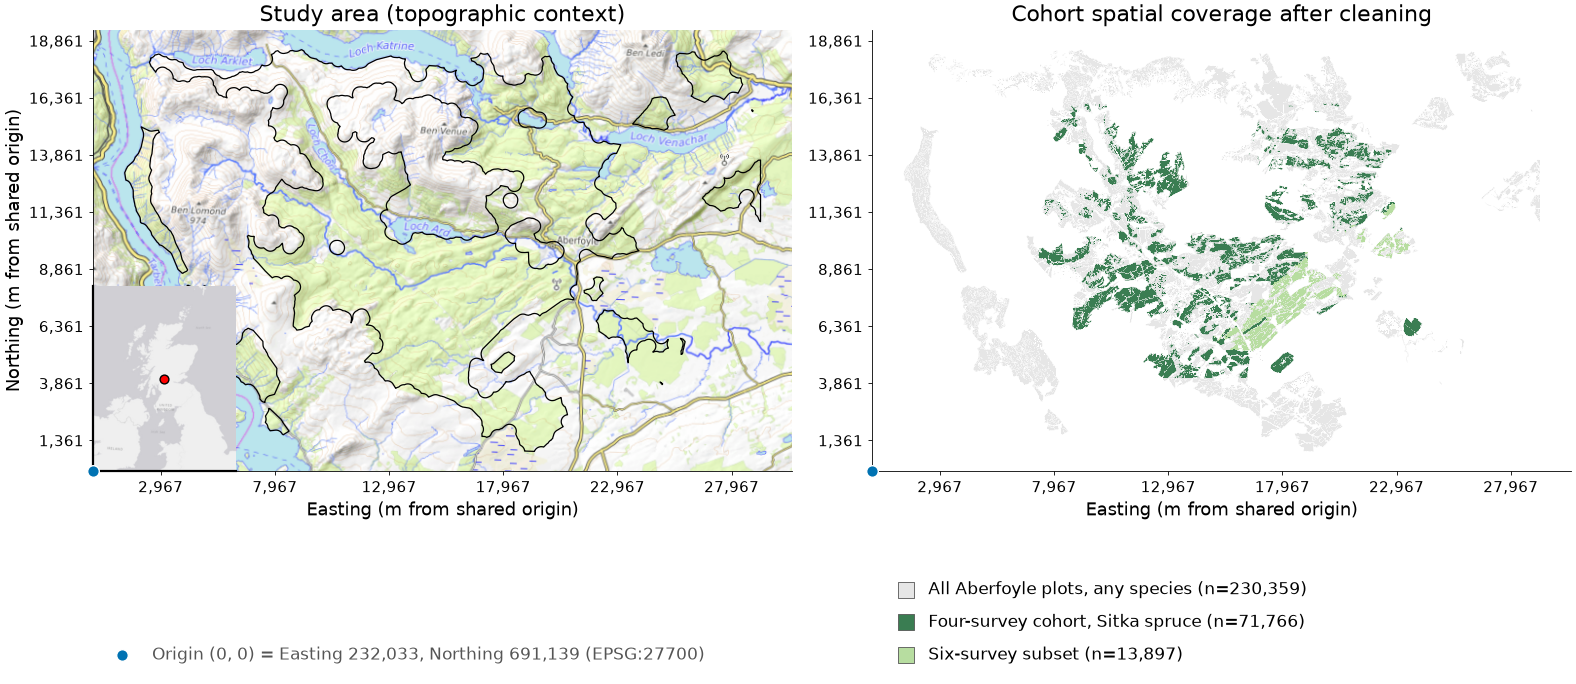

In [5]:
with style_context("default", palette_name="okabe_ito_on_white"):
    plt.rcParams["font.family"] = "DejaVu Sans"  # match methodology_figures.ipynb

    # GridSpec with a real THIRD row reserved for the caption/key, instead of the earlier
    # approach (fig.text() at negative figure-fraction coordinates + bbox_inches="tight" on
    # export). That combination forced matplotlib to re-run constrained_layout specifically
    # to compute the tight bbox, which is the likely cause of the doubled/"shadow" look on
    # the titles and axis labels (the only text constrained_layout repositions -- data fills
    # were unaffected, consistent with what was reported). This version reserves the caption
    # row NATIVELY within constrained_layout's own (0,1) managed area, so no tight-bbox
    # re-layout pass is needed at all.
    fig = plt.figure(figsize=(400 / 25.4, 190 / 25.4), layout="constrained")
    gs = fig.add_gridspec(2, 2, height_ratios=[8, 1.4])
    ax_topo = fig.add_subplot(gs[0, 0])
    ax_cohort = fig.add_subplot(gs[0, 1])
    ax_caption = fig.add_subplot(gs[1, :])
    ax_caption.axis("off")

    # Blue dot colour used both on the maps (marking the shared origin) and in the caption
    # key (marking the origin note) -- Okabe-Ito "blue", already loaded in cell 1.
    ORIGIN_DOT_COLOR = OKABE_ITO["blue"]  # "#0072B2"

    # ============================== Panel A: topo context ==============================
    ax_topo.set_xlim(*shared_xlim)
    ax_topo.set_ylim(*shared_ylim)

    # Darken the OpenTopoMap tiles slightly. NOTE on which line does what: contextily's
    # add_basemap() has no "brightness" argument, and passing alpha= to it blends the tiles
    # TOWARDS WHITE (the axes background), which lightens/mutes jarring colour rather than
    # truly darkening the image -- that is a real, deliberate choice here (a semi-transparent
    # BLACK rectangle placed on top of the basemap, below, is what would truly darken it).
    # Given the earlier complaint was about the basemap looking "jarring" (over-saturated),
    # the white-blend (alpha on add_basemap) is the one actually used below -- if the
    # intent was literal darkening instead of muting, swap this for the black Rectangle
    # overlay described in this comment.
    if HAVE_CONTEXTILY:
        ctx.add_basemap(
            ax_topo, crs=blocks.crs.to_string(), source=ctx.providers.OpenTopoMap, zorder=1,
            attribution=False, alpha=0.75,  # <-- this alpha= is the brightness/muting control
        )
    smoothed_boundary_gs.plot(ax=ax_topo, facecolor="none", edgecolor="black", linewidth=0.9, zorder=3)
    ax_topo.set_aspect("equal")
    ax_topo.set_title("Study area (topographic context)", fontsize=16)
    # Left/bottom spines left VISIBLE (matching ax_cohort's default) -- previously hidden
    # here, which meant the only black vertical line near the y-axis was the inset's own
    # small border, making the real axis look like it stopped partway up the panel.

    # Blue dot marking the shared origin (0, 0) -- the point where the two relative-distance
    # axes actually meet, i.e. (shared_origin_x, shared_origin_y), which by construction is
    # exactly the bottom-left corner of shared_xlim/shared_ylim. clip_on=False keeps the full
    # marker visible even though it sits exactly on the axes edge (half of it would otherwise
    # be clipped by the axes frame).
    ax_topo.scatter(
        [shared_origin_x], [shared_origin_y], s=70, color=ORIGIN_DOT_COLOR,
        edgecolor="white", linewidth=1.0, zorder=25, clip_on=False,
    )

    # UK-context inset, pushed to the TRUE bottom-left corner. Root cause of the earlier
    # "still not in the corner" gap, confirmed by measuring get_window_extent() directly:
    # inset_axes([0.0, 0.0, w, h]) allocates a box that inherits ax_topo's own (wide) aspect
    # ratio, but the inset's OWN data (UK north-south extent) is taller than it is wide, so
    # set_aspect("equal") on the inset shrinks its drawn content to fit -- and by default
    # (anchor="C") CENTRES that smaller content inside the wider allocated box, which is
    # exactly the left/right gap that was visible. set_anchor("SW") makes it hug the
    # bottom-left corner of its allocated box instead of centring. Size bumped 0.30 -> 0.42
    # (of ax_topo's own box, in each dimension) per feedback to make the inset bigger.
    if HAVE_CONTEXTILY:
        inset_ax = ax_topo.inset_axes([0.0, 0.0, 0.42, 0.42])
        centre_x = (shared_xlim[0] + shared_xlim[1]) / 2
        centre_y = (shared_ylim[0] + shared_ylim[1]) / 2
        half_width_m = 350_000
        inset_ax.set_xlim(centre_x - half_width_m, centre_x + half_width_m)
        inset_ax.set_ylim(centre_y - half_width_m * 1.3, centre_y + half_width_m * 1.3)
        ctx.add_basemap(inset_ax, crs=blocks.crs.to_string(), source=ctx.providers.Esri.WorldGrayCanvas, zorder=1, attribution=False)
        inset_ax.scatter([centre_x], [centre_y], color="red", s=40, zorder=5, edgecolor="black", linewidth=1)
        inset_ax.set_aspect("equal")
        inset_ax.set_anchor("SW")  # <-- the actual fix: hug the corner instead of centring
        inset_ax.set_facecolor("white")
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])
        for spine in inset_ax.spines.values():
            spine.set_linewidth(1.6)
            spine.set_edgecolor("black")
            spine.set_zorder(10)

    # ============================ Panel B: cohort coverage ============================
    ax_cohort.set_xlim(*shared_xlim)
    ax_cohort.set_ylim(*shared_ylim)

    all_plot_polygons.plot(ax=ax_cohort, color="#E6E6E6", edgecolor="none", zorder=2)
    four_survey_only_polygons.plot(ax=ax_cohort, color="#3A7D52", edgecolor="none", zorder=3)  # dark green
    six_survey_polygons.plot(ax=ax_cohort, color="#B7DDA0", edgecolor="none", zorder=4)  # light green

    ax_cohort.set_aspect("equal")
    ax_cohort.set_title("Cohort spatial coverage after cleaning", fontsize=16)

    # Same shared-origin blue dot, so both panels visually confirm they share one real-world
    # coordinate reference.
    ax_cohort.scatter(
        [shared_origin_x], [shared_origin_y], s=70, color=ORIGIN_DOT_COLOR,
        edgecolor="white", linewidth=1.0, zorder=25, clip_on=False,
    )

    # ==================== Shared relative-distance axes, both panels ====================
    for ax in (ax_topo, ax_cohort):
        ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"{val - shared_origin_x:,.0f}"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"{val - shared_origin_y:,.0f}"))
        ax.set_xlabel("Easting (m from shared origin)", fontsize=13)
        ax.tick_params(labelsize=11)
    ax_topo.set_ylabel("Northing (m from shared origin)", fontsize=13)

    # ==================== Caption row: origin note BOTTOM-LEFT, legend RIGHT ====================
    # Origin note, bottom-left of the caption row, with a matching blue dot just to its
    # left -- the same dot colour used on the maps, so the two are visually linked.
    origin_note_y = 0.22
    origin_dot_x = 0.02
    ax_caption.scatter(
        [origin_dot_x], [origin_note_y], s=70, color=ORIGIN_DOT_COLOR,
        edgecolor="white", linewidth=1.0, transform=ax_caption.transAxes, clip_on=False, zorder=25,
    )
    ax_caption.text(
        origin_dot_x + 0.02, origin_note_y,
        f"Origin (0, 0) = Easting {shared_origin_x:,.0f}, Northing {shared_origin_y:,.0f} (EPSG:27700)",
        ha="left", va="center", fontsize=12, color=COLOR_NEUTRAL_EDGE, transform=ax_caption.transAxes,
    )

    # Cohort legend, right side of the caption row, stacked vertically.
    key_entries = [
        ("#E6E6E6", f"All Aberfoyle plots, any species (n={len(all_plot_polygons):,})"),
        ("#3A7D52", f"Four-survey cohort, Sitka spruce (n={len(four_survey_only_polygons) + len(six_survey_polygons):,})"),
        ("#B7DDA0", f"Six-survey subset (n={len(six_survey_polygons):,})"),
    ]
    # Scatter markers instead of draw_color_key's Rectangle -- ax_caption is a short, wide
    # axes (~14:1 aspect), so a "square" defined in axes-FRACTION coordinates (same value
    # for width and height) rendered as a thin horizontal sliver, not a square, confirmed
    # directly in an earlier render. Scatter marker size is in POINTS (a fixed physical
    # size), which stays visually square regardless of the axes' own aspect ratio.
    key_x = 0.55
    key_y = 0.82
    key_row_gap = 0.30
    for color, label in key_entries:
        ax_caption.scatter(
            [key_x], [key_y], s=120, marker="s", color=color, edgecolor=COLOR_NEUTRAL_EDGE,
            linewidth=0.6, transform=ax_caption.transAxes, clip_on=False, zorder=20,
        )
        ax_caption.text(key_x + 0.015, key_y, label, fontsize=12, va="center", ha="left", transform=ax_caption.transAxes)
        key_y -= key_row_gap

    plt.show()


## Export

In [6]:
output_dir = PROJECT_ROOT / "outputs" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

report = export_figure(
    fig,
    str(output_dir / "fig3_2a_cohort_coverage_map"),
    formats=["png", "pdf"],
    dpi=600,
    overwrite=True,
    # bbox_inches left at the default (None) -- the caption now lives in a real GridSpec
    # row that constrained_layout manages natively, so no tight-bbox re-layout pass is
    # needed (that pass was the likely cause of the earlier "shadow" text artifact).
    provenance={
        "raw_data": [
            "data/raw/LiDAR_Years_All_7jul.gpkg (layer LiDAR_Years, real plot geometry, ALL species)",
            "data/interim/block_boundaries.parquet",
            "data/processed/environmental/plot_environmental_features.parquet",
            "data/processed/master/clean_master_6survey.parquet",
        ],
        "transformations": [
            "plot-level join, cohort-membership flag, shared extent from block-boundary union",
        ],
        "basemap": "OpenTopoMap (panel A) + Esri WorldGrayCanvas (inset) via contextily, fetched <DATE>",
    },
    write_manifest=True,
)
print(report)

{'schema_version': '1.0', 'outputs': [{'path': '/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/figures/fig3_2a_cohort_coverage_map.png', 'format': 'png', 'kind': 'raster', 'size_bytes': 13129181}, {'path': '/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/figures/fig3_2a_cohort_coverage_map.pdf', 'format': 'pdf', 'kind': 'vector-container', 'size_bytes': 20293163}], 'settings': {'formats': ['png', 'pdf'], 'dpi': 600.0, 'transparent': False, 'bbox_inches': None, 'pad_inches': 0.1, 'facecolor': 'white', 'font_mode': 'truetype', 'figure_size_inches': [15.748031496062993, 7.480314960629921]}, 'versions': {'matplotlib': '3.11.0', 'pillow': '12.2.0'}, 'provenance': {'raw_data': ['data/raw/LiDAR_Years_All_7jul.gpkg (layer LiDAR_Years, real plot geometry, ALL species)', 'data/interim/block_boundaries.parquet', 'data/processed/environmental/plot_environmental_features.parquet', 'data/processed/master/clean_master_6survey.parquet'], 'transformations': ['plot-level

---

## 3. Figure 3.2, Panel B -- cleaning funnel

**Kept as a plain LaTeX table** (`tab:data-funnel`, already in the chapter draft) rather than a
chart -- no figure built here. Those numbers were live-verified earlier this session directly
against `data_processing/clean_master_data.py::clean_cohort()` (not just trusted as hardcoded);
that verification isn't reproduced in this notebook, since it isn't producing anything visual.

---

## 4. Sub-compartment zoom -- compartment/sub-compartment boundary intersection

A close-up of a single compartment/sub-compartment boundary intersection, showing individual
20 x 20 m plots at their actual size: a regular plot (centre = polygon centroid) next to a
boundary-clipped plot (centre = `representative_point()`, the same fallback rule
`models/common/export_coordinates.py` uses whenever a plot's centroid falls outside its own
polygon), plus the species/cohort mix of the plots nearby.

This is a **separate figure for now** (its own PNG) -- the plan is to place it in a row
alongside the two Figure 3.2 panels above once it's confirmed to look right; not merged into
that GridSpec yet.


In [7]:
# ==================== Sub-compartment zoom: one compartment/sub-compartment ====================
# ==================== boundary intersection, showing individual 20x20m plots ====================
# This is a SEPARATE figure (not part of the two-panel Figure 3.2 above) -- a close-up showing
# what the underlying plot grid actually looks like: regular 20 x 20 m cells, plots clipped by
# a compartment/sub-compartment boundary, and species/cohort mix at the individual-plot level.
# Per the plan, this will later sit in a row alongside the two panels above; for now it is its
# own PNG.
from shapely.geometry import box

# Same shared origin as Figure 3.2 -- recomputed from the same block-boundary bounds, so the
# relative-distance axis ticks here are directly comparable to the wider maps above, even
# though the visible range is now only a few hundred metres of a >20km-wide study area. That
# is deliberate: (0, 0) must mean the same real-world point everywhere in this notebook.
assert shared_origin_x is not None and shared_origin_y is not None  # defined in the cell above

# Window centre and size were chosen by scanning "clipped" 4-survey plots (centroid outside
# its own polygon -- see the note on is_clipped below) that also sit close to the outer edge
# of the study area, so the window's rough position is identifiable against the wider study
# area map (Figure 3.2 above), while still crossing real internal compartment/sub-compartment
# boundaries (not just the outer block edge, which -- checked separately -- turned out to
# have very little internal structure: only 1 compartment/sub-compartment and 2 species right
# at the edge). That search is not reproduced here (one-off exploratory data analysis, not
# part of the figure itself) -- these are its result.
zoom_centre_x, zoom_centre_y = 251485.822468, 698758.640043
zoom_half_width, zoom_half_height = 150, 220  # metres -- 300 x 440m window, taller than wide
zoom_window = box(
    zoom_centre_x - zoom_half_width, zoom_centre_y - zoom_half_height,
    zoom_centre_x + zoom_half_width, zoom_centre_y + zoom_half_height,
)

# A plot's geometric centroid can fall OUTSIDE its own polygon for an oddly-shaped (e.g.
# boundary-clipped) plot. models/common/export_coordinates.py handles this by falling back to
# representative_point() (a guaranteed-interior point) whenever that happens -- this notebook
# uses the exact same rule so the "clipped plot" example below matches the project's own
# plot-centre convention used elsewhere in the pipeline.
zoom_plots = raw_plot_polygons[raw_plot_polygons.geometry.centroid.within(zoom_window)].copy()
zoom_plots["centroid"] = zoom_plots.geometry.centroid
zoom_plots["is_clipped"] = ~zoom_plots["centroid"].within(zoom_plots.geometry)
print(f"{len(zoom_plots)} plots in the zoom window, {zoom_plots['is_clipped'].sum()} clipped")
print(zoom_plots["Species"].value_counts())

# Category: Sitka spruce split by cohort (matching the two-panel figure's colours exactly),
# every other species gets its own colour -- codes are used as-is (e.g. "BI", "SP", "XC")
# rather than expanded to English names, since only "SS = Sitka spruce" is confirmed anywhere
# in this project's documentation (the terms cheat sheet); the others are not verified there,
# so inventing full species names for the legend would violate this chapter's own
# verified-facts-only rule.
# Species is used as-is (the plot's own category), including "SS" -- no cohort split here.
zoom_plots["category"] = zoom_plots["Species"]

ZOOM_CATEGORY_COLORS = {
    "SS": "#3A7D52",  # same dark green Figure 3.2 uses for the 4-survey Sitka spruce cohort
    "BI": OKABE_ITO["orange"],
    "NS": OKABE_ITO["bluish_green"],
    "SP": OKABE_ITO["vermillion"],
}

# Compartment and sub-compartment boundaries, clipped to a slightly wider window than the
# plotted extent so lines don't look like they stop abruptly right at the axes edge.
compartment_boundaries = gpd.read_parquet(PROJECT_ROOT / "data/interim/compartment_boundaries.parquet")
subcompartment_boundaries = gpd.read_parquet(PROJECT_ROOT / "data/interim/subcompartment_boundaries.parquet")
zoom_context_window = box(
    zoom_centre_x - zoom_half_width - 40, zoom_centre_y - zoom_half_height - 40,
    zoom_centre_x + zoom_half_width + 40, zoom_centre_y + zoom_half_height + 40,
)
zoom_compartment_boundaries = compartment_boundaries[compartment_boundaries.intersects(zoom_context_window)]
zoom_subcompartment_boundaries = subcompartment_boundaries[subcompartment_boundaries.intersects(zoom_context_window)]
# Compartments actually visible within the plotted window (not the wider context window above),
# used only for the panel title, so the title doesn't claim a compartment is "in" the figure
# when it only clips the margin outside the visible extent.
zoom_visible_compartments = sorted(
    compartment_boundaries[compartment_boundaries.intersects(zoom_window)]["cpmt"].tolist()
)
print(f"Compartments visible in window: {zoom_visible_compartments}")

# The two example plots this figure exists to contrast -- chosen from the search described
# above: a "clean" ~400m2 regular plot (centroid = true centre) and a boundary-clipped plot
# (centroid falls outside its own polygon, representative_point() fallback used instead).
ZOOM_REGULAR_EXAMPLE_ID = 353000
ZOOM_CLIPPED_EXAMPLE_ID = 357844
_regular_geom = raw_plot_polygons.loc[raw_plot_polygons["identification"] == ZOOM_REGULAR_EXAMPLE_ID, "geometry"].iloc[0]
_clipped_geom = raw_plot_polygons.loc[raw_plot_polygons["identification"] == ZOOM_CLIPPED_EXAMPLE_ID, "geometry"].iloc[0]
zoom_regular_centre = _regular_geom.centroid
_clipped_centroid = _clipped_geom.centroid
zoom_clipped_centre = (
    _clipped_centroid if _clipped_centroid.within(_clipped_geom) else _clipped_geom.representative_point()
)
print(f"Regular example plot {ZOOM_REGULAR_EXAMPLE_ID}: centre = centroid, area {_regular_geom.area:.1f} m2")
print(
    f"Clipped example plot {ZOOM_CLIPPED_EXAMPLE_ID}: centroid inside polygon = "
    f"{_clipped_centroid.within(_clipped_geom)}, area {_clipped_geom.area:.1f} m2"
)


198 plots in the zoom window, 4 clipped
Species
SS    136
SP     39
NS     12
BI     11
Name: count, dtype: int64
Compartments visible in window: [2220, 2226, 2227, 2228]
Regular example plot 353000: centre = centroid, area 400.0 m2
Clipped example plot 357844: centroid inside polygon = False, area 800.6 m2


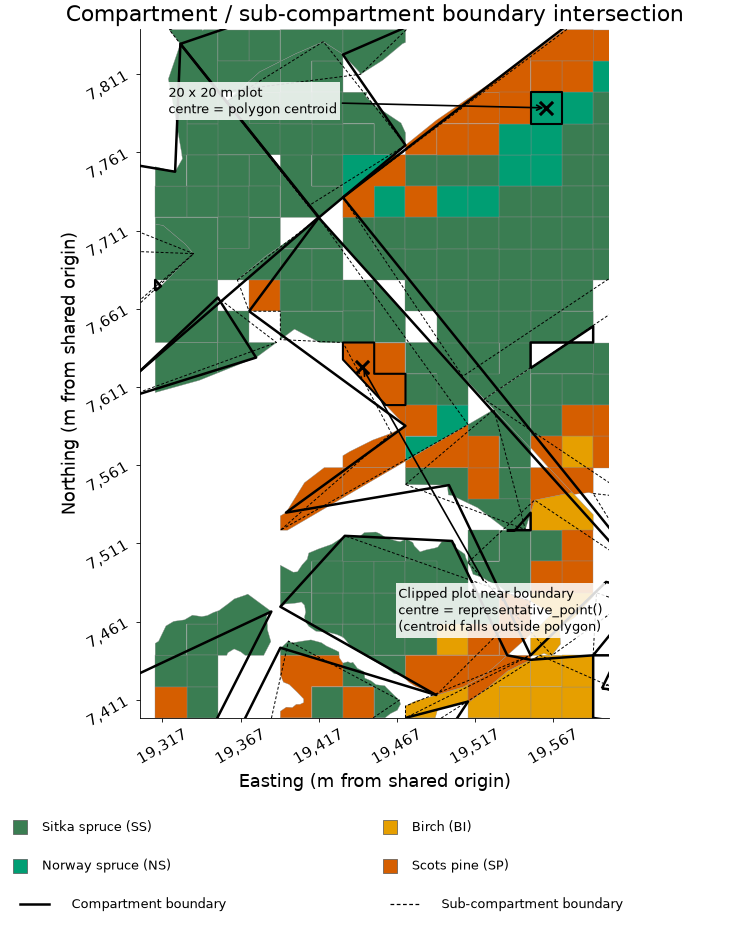

In [8]:
with style_context("default", palette_name="okabe_ito_on_white"):
    plt.rcParams["font.family"] = "DejaVu Sans"  # match methodology_figures.ipynb

    # Taller-than-wide, per the requested orientation -- main map on top, legend strip below
    # (same GridSpec-row pattern as Figure 3.2, for the same reason: constrained_layout needs
    # a real row to reserve space for, not off-canvas fig.text()).
    fig = plt.figure(figsize=(190 / 25.4, 235 / 25.4), layout="constrained")
    gs = fig.add_gridspec(2, 1, height_ratios=[8, 1.4])
    ax = fig.add_subplot(gs[0, 0])
    ax_leg = fig.add_subplot(gs[1, 0])
    ax_leg.axis("off")

    # Each species/cohort category gets its own fill -- plotted category-by-category (rather
    # than one .plot() call with a column= argument) so the colour mapping is the exact same
    # ZOOM_CATEGORY_COLORS dict used by the legend below, not a colormap matplotlib chooses.
    # Thin, LIGHT grey edges (not the earlier dark #555555 at 0.3pt, which read as a busy
    # black grid) -- with only 4 colour categories now and "SS" alone covering most of the
    # window, some edge is still needed so individual 20x20m plots stay visible as a grid
    # instead of merging into one solid colour blob; a light, thin one keeps that without
    # being the dominant visual element it was before.
    for category, color in ZOOM_CATEGORY_COLORS.items():
        subset = zoom_plots[zoom_plots["category"] == category]
        if len(subset):
            subset.plot(ax=ax, color=color, edgecolor="#8C8C8C", linewidth=0.25, zorder=3)

    # Sub-compartment boundaries (thin, dashed) UNDER compartment boundaries (thick, solid) --
    # unlike the wide study-area map, these are NOT morphologically smoothed. At this zoom
    # scale the boundary's exact shape (including the small notches/slivers that create clipped
    # plots in the first place) is the whole point of the figure, so smoothing it away here
    # would misrepresent the thing being shown.
    zoom_subcompartment_boundaries.boundary.plot(
        ax=ax, edgecolor="black", linewidth=0.7, linestyle=(0, (3, 2)), zorder=5,
    )
    zoom_compartment_boundaries.boundary.plot(ax=ax, edgecolor="black", linewidth=1.8, zorder=6)

    ax.set_xlim(zoom_centre_x - zoom_half_width, zoom_centre_x + zoom_half_width)
    ax.set_ylim(zoom_centre_y - zoom_half_height, zoom_centre_y + zoom_half_height)
    ax.set_aspect("equal")

    # The two contrast examples: a marker at each plot's actual centre (per
    # export_coordinates.py's own centroid / representative_point() fallback rule), with a
    # callout explaining which rule applied and why.
    zoom_plots[zoom_plots["identification"] == ZOOM_REGULAR_EXAMPLE_ID].plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=1.5, zorder=9,
    )
    ax.scatter(
        [zoom_regular_centre.x], [zoom_regular_centre.y], marker="x", s=90, color="black",
        linewidth=2.2, zorder=10,
    )
    ax.annotate(
        "20 x 20 m plot\ncentre = polygon centroid",
        xy=(zoom_regular_centre.x, zoom_regular_centre.y), xytext=(0.06, 0.92), textcoords="axes fraction",
        fontsize=9, ha="left", va="top", arrowprops=dict(arrowstyle="->", color="black", lw=1.2), zorder=15,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2),
    )
    zoom_plots[zoom_plots["identification"] == ZOOM_CLIPPED_EXAMPLE_ID].plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=1.5, zorder=9,
    )
    ax.scatter(
        [zoom_clipped_centre.x], [zoom_clipped_centre.y], marker="x", s=90, color="black",
        linewidth=2.2, zorder=10,
    )
    ax.annotate(
        "Clipped plot near boundary\ncentre = representative_point()\n(centroid falls outside polygon)",
        xy=(zoom_clipped_centre.x, zoom_clipped_centre.y), xytext=(0.55, 0.12), textcoords="axes fraction",
        fontsize=9, ha="left", va="bottom", arrowprops=dict(arrowstyle="->", color="black", lw=1.2), zorder=15,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2),
    )

    # Same shared-origin relative-distance axes as Figure 3.2 above -- (0, 0) is the same
    # real-world point (bottom-left corner of the padded block-boundary extent), just zoomed
    # in here to a ~220 x 320m window instead of the whole study area.
    ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"{val - shared_origin_x:,.0f}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"{val - shared_origin_y:,.0f}"))
    ax.set_xlabel("Easting (m from shared origin)", fontsize=13)  # match Figure 3.2
    ax.set_ylabel("Northing (m from shared origin)", fontsize=13)
    ax.tick_params(labelsize=11, rotation=30)
    # Kept short and fixed, not dynamically built from the compartment list -- measured
    # directly (fig.canvas.draw() + get_window_extent()) that even the "N compartments: ..."
    # short form was ~110% of the figure's own width and got clipped at export. The full
    # compartment list is still printed by the data-prep cell above, just not on the canvas.
    ax.set_title("Compartment / sub-compartment boundary intersection", fontsize=16)  # match Figure 3.2

    # Legend: species/cohort swatches (2 columns) + boundary line styles, same scatter-marker
    # trick as Figure 3.2's caption row (fixed physical size in points, so swatches render as
    # true squares regardless of this axes' own aspect ratio).
    zoom_legend_categories = ["SS", "BI", "NS", "SP"]
    zoom_legend_labels = {
        "SS": "Sitka spruce (SS)", "BI": "Birch (BI)",
        "NS": "Norway spruce (NS)", "SP": "Scots pine (SP)",
    }
    ncol = 2
    x_positions = [0.02, 0.52]
    y_start = 0.78
    row_gap = 0.32
    for i, category in enumerate(zoom_legend_categories):
        col, row = i % ncol, i // ncol
        x, y = x_positions[col], y_start - row * row_gap
        ax_leg.scatter(
            [x], [y], s=110, marker="s", color=ZOOM_CATEGORY_COLORS[category], edgecolor=COLOR_NEUTRAL_EDGE,
            linewidth=0.5, transform=ax_leg.transAxes, clip_on=False, zorder=20,
        )
        ax_leg.text(x + 0.03, y, zoom_legend_labels[category], fontsize=9, va="center", ha="left", transform=ax_leg.transAxes)

    line_y = y_start - 2 * row_gap
    ax_leg.plot([0.02, 0.06], [line_y, line_y], color="black", linewidth=1.8, transform=ax_leg.transAxes, clip_on=False)
    ax_leg.text(0.09, line_y, "Compartment boundary", fontsize=9, va="center", ha="left", transform=ax_leg.transAxes)
    ax_leg.plot(
        [0.52, 0.56], [line_y, line_y], color="black", linewidth=0.9, linestyle=(0, (3, 2)),
        transform=ax_leg.transAxes, clip_on=False,
    )
    ax_leg.text(0.59, line_y, "Sub-compartment boundary", fontsize=9, va="center", ha="left", transform=ax_leg.transAxes)

    plt.show()


## Export

In [9]:
output_dir = PROJECT_ROOT / "outputs" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

report = export_figure(
    fig,
    str(output_dir / "fig3_2c_subcompartment_zoom"),
    formats=["png", "pdf"],
    dpi=400,
    overwrite=True,
    provenance={
        "raw_data": "data/raw/LiDAR_Years_All_7jul.gpkg (layer LiDAR_Years), "
                    "data/interim/compartment_boundaries.parquet, "
                    "data/interim/subcompartment_boundaries.parquet, "
                    "data/processed/master/clean_master_6survey.parquet",
        "transformations": [
            f"zoom window centred at ({zoom_centre_x:.1f}, {zoom_centre_y:.1f}), "
            f"half-extent ({zoom_half_width}, {zoom_half_height}) m",
            "is_clipped = centroid falls outside own polygon (export_coordinates.py convention)",
        ],
    },
    write_manifest=True,
)
print(report)


{'schema_version': '1.0', 'outputs': [{'path': '/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/figures/fig3_2c_subcompartment_zoom.png', 'format': 'png', 'kind': 'raster', 'size_bytes': 916308}, {'path': '/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/figures/fig3_2c_subcompartment_zoom.pdf', 'format': 'pdf', 'kind': 'vector-container', 'size_bytes': 46944}], 'settings': {'formats': ['png', 'pdf'], 'dpi': 400.0, 'transparent': False, 'bbox_inches': None, 'pad_inches': 0.1, 'facecolor': 'white', 'font_mode': 'truetype', 'figure_size_inches': [7.480314960629921, 9.25196850393701]}, 'versions': {'matplotlib': '3.11.0', 'pillow': '12.2.0'}, 'provenance': {'raw_data': 'data/raw/LiDAR_Years_All_7jul.gpkg (layer LiDAR_Years), data/interim/compartment_boundaries.parquet, data/interim/subcompartment_boundaries.parquet, data/processed/master/clean_master_6survey.parquet', 'transformations': ['zoom window centred at (251485.8, 698758.6), half-extent (150, 220) m'

## LaTeX snippet (paste into Overleaf)

```latex
\begin{figure}[htbp]
    \centering
    \includegraphics[width=0.55\textwidth]{figures/fig3_2c_subcompartment_zoom.pdf}
    \caption{Compartment/sub-compartment boundary intersection, showing individual
    $20\times20$\,m plots. A regular plot's centre is its polygon centroid; a
    boundary-clipped plot's centre falls back to \texttt{representative\_point()} whenever
    the centroid itself lies outside the clipped polygon (the same rule used in
    \texttt{models/common/export\_coordinates.py}). Origin $(0,0)$ is the same real-world
    point used throughout this chapter's figures.}
    \label{fig:data-subcompartment-zoom}
\end{figure}
```


---

## 5. Combined figure -- all three panels side by side

Single row, left to right: (A) topographic context, (B) cohort spatial coverage, (C)
sub-compartment zoom -- the zoom-in is last, matching the lettering to reading order (an
earlier version put it first/leftmost but still labelled it (A), which didn't match). Column
widths are set to each panel's own data aspect ratio (1 : 1 : 0.43 -- the two landscape panels
vs. the portrait zoom), not equal thirds, so no panel ends up with dead space around it.

Titles are shorter than the standalone versions above, to fit the narrower columns.


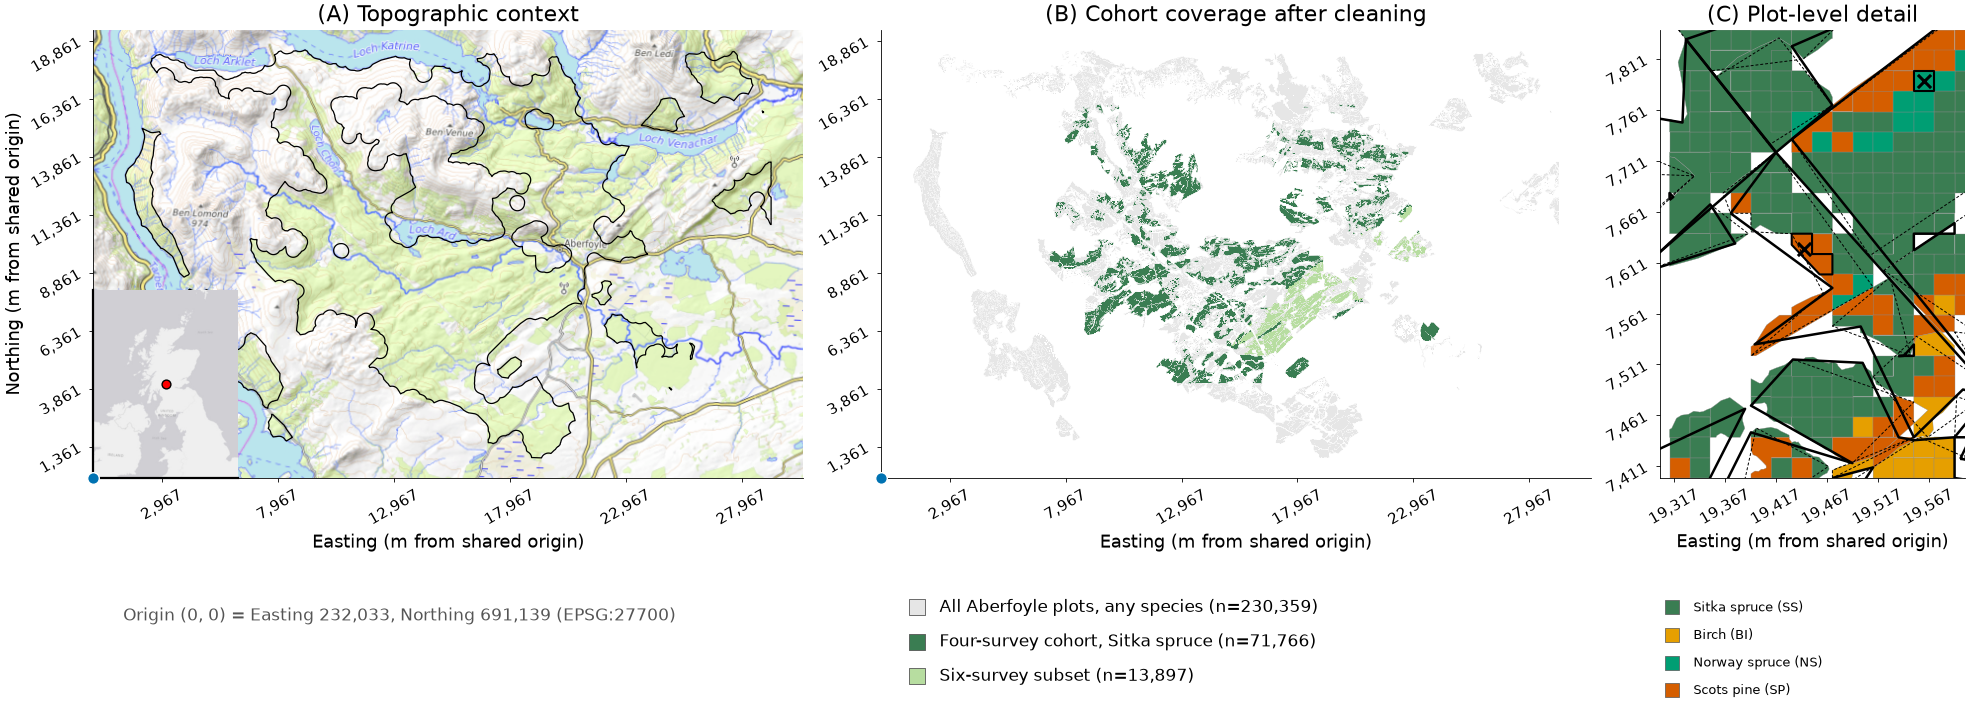

In [10]:
with style_context("default", palette_name="okabe_ito_on_white"):
    plt.rcParams["font.family"] = "DejaVu Sans"  # match methodology_figures.ipynb

    # Panel order is (A) topo, (B) cohort, (C) zoom -- left to right, matching the lettering
    # (earlier version had zoom on the left as an unlettered "leftmost" panel, but labelled it
    # (A); moved here so the letters and reading order agree, with the zoom-in as the last,
    # most-detailed panel).
    #
    # Column widths still follow each panel's own data aspect ratio (1 : 1 : 0.43 -- the two
    # landscape panels vs. the portrait zoom, now last), so no panel has dead space around it
    # -- confirmed empirically before writing this cell, the same way the earlier inset-corner
    # fix was verified (draw + measure, not guessed).
    fig = plt.figure(figsize=(500 / 25.4, 200 / 25.4), layout="constrained")
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.43], height_ratios=[8, 1.4])
    ax_topo = fig.add_subplot(gs[0, 0])
    ax_cohort = fig.add_subplot(gs[0, 1])
    ax_zoom = fig.add_subplot(gs[0, 2])
    ax_cap_main = fig.add_subplot(gs[1, 0:2])
    ax_cap_main.axis("off")
    ax_cap_zoom = fig.add_subplot(gs[1, 2])
    ax_cap_zoom.axis("off")

    # ============================== Panel A: topo context ==============================
    ax_topo.set_xlim(*shared_xlim)
    ax_topo.set_ylim(*shared_ylim)
    if HAVE_CONTEXTILY:
        ctx.add_basemap(
            ax_topo, crs=blocks.crs.to_string(), source=ctx.providers.OpenTopoMap, zorder=1,
            attribution=False, alpha=0.75,
        )
    smoothed_boundary_gs.plot(ax=ax_topo, facecolor="none", edgecolor="black", linewidth=0.9, zorder=3)
    ax_topo.set_aspect("equal")
    ax_topo.set_title("(A) Topographic context", fontsize=16)

    ax_topo.scatter(
        [shared_origin_x], [shared_origin_y], s=70, color=ORIGIN_DOT_COLOR,
        edgecolor="white", linewidth=1.0, zorder=25, clip_on=False,
    )
    if HAVE_CONTEXTILY:
        inset_ax = ax_topo.inset_axes([0.0, 0.0, 0.42, 0.42])
        centre_x = (shared_xlim[0] + shared_xlim[1]) / 2
        centre_y = (shared_ylim[0] + shared_ylim[1]) / 2
        half_width_m = 350_000
        inset_ax.set_xlim(centre_x - half_width_m, centre_x + half_width_m)
        inset_ax.set_ylim(centre_y - half_width_m * 1.3, centre_y + half_width_m * 1.3)
        ctx.add_basemap(inset_ax, crs=blocks.crs.to_string(), source=ctx.providers.Esri.WorldGrayCanvas, zorder=1, attribution=False)
        inset_ax.scatter([centre_x], [centre_y], color="red", s=40, zorder=5, edgecolor="black", linewidth=1)
        inset_ax.set_aspect("equal")
        inset_ax.set_anchor("SW")
        inset_ax.set_facecolor("white")
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])
        for spine in inset_ax.spines.values():
            spine.set_linewidth(1.6)
            spine.set_edgecolor("black")
            spine.set_zorder(10)

    # ============================ Panel B: cohort coverage ============================
    ax_cohort.set_xlim(*shared_xlim)
    ax_cohort.set_ylim(*shared_ylim)
    all_plot_polygons.plot(ax=ax_cohort, color="#E6E6E6", edgecolor="none", zorder=2)
    four_survey_only_polygons.plot(ax=ax_cohort, color="#3A7D52", edgecolor="none", zorder=3)
    six_survey_polygons.plot(ax=ax_cohort, color="#B7DDA0", edgecolor="none", zorder=4)
    ax_cohort.set_aspect("equal")
    ax_cohort.set_title("(B) Cohort coverage after cleaning", fontsize=16)
    ax_cohort.scatter(
        [shared_origin_x], [shared_origin_y], s=70, color=ORIGIN_DOT_COLOR,
        edgecolor="white", linewidth=1.0, zorder=25, clip_on=False,
    )

    # ============================== Panel C: sub-compartment zoom ==============================
    for category, color in ZOOM_CATEGORY_COLORS.items():
        subset = zoom_plots[zoom_plots["category"] == category]
        if len(subset):
            subset.plot(ax=ax_zoom, color=color, edgecolor="#8C8C8C", linewidth=0.25, zorder=3)
    zoom_subcompartment_boundaries.boundary.plot(
        ax=ax_zoom, edgecolor="black", linewidth=0.7, linestyle=(0, (3, 2)), zorder=5,
    )
    zoom_compartment_boundaries.boundary.plot(ax=ax_zoom, edgecolor="black", linewidth=1.8, zorder=6)
    ax_zoom.set_xlim(zoom_centre_x - zoom_half_width, zoom_centre_x + zoom_half_width)
    ax_zoom.set_ylim(zoom_centre_y - zoom_half_height, zoom_centre_y + zoom_half_height)
    ax_zoom.set_aspect("equal")
    zoom_plots[zoom_plots["identification"] == ZOOM_REGULAR_EXAMPLE_ID].plot(
        ax=ax_zoom, facecolor="none", edgecolor="black", linewidth=1.5, zorder=9,
    )
    ax_zoom.scatter(
        [zoom_regular_centre.x], [zoom_regular_centre.y], marker="x", s=90, color="black",
        linewidth=2.2, zorder=10,
    )
    zoom_plots[zoom_plots["identification"] == ZOOM_CLIPPED_EXAMPLE_ID].plot(
        ax=ax_zoom, facecolor="none", edgecolor="black", linewidth=1.5, zorder=9,
    )
    ax_zoom.scatter(
        [zoom_clipped_centre.x], [zoom_clipped_centre.y], marker="x", s=90, color="black",
        linewidth=2.2, zorder=10,
    )
    ax_zoom.set_title("(C) Plot-level detail", fontsize=16)

    # ==================== Shared relative-distance axes, all three panels ====================
    for ax in (ax_topo, ax_cohort, ax_zoom):
        ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"{val - shared_origin_x:,.0f}"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"{val - shared_origin_y:,.0f}"))
        ax.set_xlabel("Easting (m from shared origin)", fontsize=13)
        ax.tick_params(labelsize=11, rotation=30)
    ax_topo.set_ylabel("Northing (m from shared origin)", fontsize=13)  # leftmost panel now

    # ==================== Panels A+B's shared caption: origin note (left) + cohort key (right) ====================
    ax_cap_main.text(
        0.02, 0.85,
        f"Origin (0, 0) = Easting {shared_origin_x:,.0f}, Northing {shared_origin_y:,.0f} (EPSG:27700)",
        ha="left", va="top", fontsize=12, color=COLOR_NEUTRAL_EDGE, transform=ax_cap_main.transAxes,
    )
    key_entries = [
        ("#E6E6E6", f"All Aberfoyle plots, any species (n={len(all_plot_polygons):,})"),
        ("#3A7D52", f"Four-survey cohort, Sitka spruce (n={len(four_survey_only_polygons) + len(six_survey_polygons):,})"),
        ("#B7DDA0", f"Six-survey subset (n={len(six_survey_polygons):,})"),
    ]
    key_y = 0.85
    for color, label in key_entries:
        ax_cap_main.scatter(
            [0.55], [key_y], s=120, marker="s", color=color, edgecolor=COLOR_NEUTRAL_EDGE,
            linewidth=0.6, transform=ax_cap_main.transAxes, clip_on=False, zorder=20,
        )
        ax_cap_main.text(0.565, key_y, label, fontsize=12, va="center", ha="left", transform=ax_cap_main.transAxes)
        key_y -= 0.3

    # ==================== Panel C's own caption: species + boundary line styles ====================
    zoom_cap_entries = ["SS", "BI", "NS", "SP"]
    for i, category in enumerate(zoom_cap_entries):
        y = 0.85 - i * 0.24
        ax_cap_zoom.scatter(
            [0.04], [y], s=110, marker="s", color=ZOOM_CATEGORY_COLORS[category], edgecolor=COLOR_NEUTRAL_EDGE,
            linewidth=0.5, transform=ax_cap_zoom.transAxes, clip_on=False, zorder=20,
        )
        ax_cap_zoom.text(
            0.11, y, zoom_legend_labels[category], fontsize=9, va="center", ha="left",
            transform=ax_cap_zoom.transAxes,
        )

    plt.show()


## Export

In [11]:
output_dir = PROJECT_ROOT / "outputs" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

report = export_figure(
    fig,
    str(output_dir / "fig3_2_combined_three_panel"),
    formats=["png", "pdf"],
    dpi=400,
    overwrite=True,
    write_manifest=True,
)
print(report)


{'schema_version': '1.0', 'outputs': [{'path': '/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/figures/fig3_2_combined_three_panel.png', 'format': 'png', 'kind': 'raster', 'size_bytes': 8044758}, {'path': '/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/figures/fig3_2_combined_three_panel.pdf', 'format': 'pdf', 'kind': 'vector-container', 'size_bytes': 16077341}], 'settings': {'formats': ['png', 'pdf'], 'dpi': 400.0, 'transparent': False, 'bbox_inches': None, 'pad_inches': 0.1, 'facecolor': 'white', 'font_mode': 'truetype', 'figure_size_inches': [19.68503937007874, 7.874015748031496]}, 'versions': {'matplotlib': '3.11.0', 'pillow': '12.2.0'}, 'provenance': {}, 'warnings': [], 'notice': 'Export completed with explicit settings. This report does not establish visual, accessibility, scientific-integrity, or journal-submission compliance.', 'manifest': '/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/outputs/figures/fig3_2_combined_three_panel.expor

## LaTeX snippet (paste into Overleaf)

```latex
\begin{figure}[htbp]
    \centering
    \includegraphics[width=\textwidth]{figures/fig3_2_combined_three_panel.pdf}
    \caption{(A) Topographic context of the study area. (B) Spatial coverage of the
    four-survey and six-survey Sitka spruce cohorts after cleaning. (C) Plot-level detail at a
    compartment/sub-compartment boundary intersection, showing individual $20\times20$\,m
    plots, a boundary-clipped plot, and species mix. All three panels share one real-world
    origin $(0,0)$.}
    \label{fig:data-three-panel}
\end{figure}
```
